In [7]:
import h5py
import numpy as np
import re
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

In [8]:
# ------------------------------------------------------------------
# 1. List of files you want to scan (each with some MeV cut(s))
# ------------------------------------------------------------------
filepaths = [
    'src/nosmash/7GeV_FinalResult1_NoSmash_80000_200PJ.h5',
    'src/nosmash/19GeV_FinalResult1_NoSmash_80000_400PJ.h5',
    'src/nosmash/27GeV_FinalResult1_NoSmash_80000_400PJ.h5',
    'src/nosmash/54GeV_FinalResult1_NoSmash_80000_500PJ.h5',
    'src/nosmash/200GeV_FinalResult1_NoSmash_80000_500PJ.h5'
]

# src/nosmash/7GeV_FinalResult1_NoSmash_80000_200PJ.h5

In [9]:
# ------------------------------------------------------------------
# 2. Helper: process one file & return POINTS at specific centrality bins
# ------------------------------------------------------------------
CENT_IDX_05   = 16  # 0-5%
CENT_IDX_3040 = 9   # 30-40%

def _as_2d(a):
    a = np.asarray(a)
    return a[:, None] if a.ndim == 1 else a

def _energy_from_filename(path):
    m = re.search(r"(\d+(?:\.\d+)?)GeV", str(path))
    if not m:
        raise ValueError(f"Couldn't parse energy from filename: {path}")
    return float(m.group(1))

def get_energy_scan_points_from_file(filepath, startpc_group="STARTPC"):
    """
    Returns records:
      (energy_GeV, estimator_idx, cent_label, y, yerr)
    using a *fixed* pT cut group (default STARTPC = 200 MeV in your convention).
    """
    E = _energy_from_filename(filepath)
    points = []

    with h5py.File(filepath, "r") as hdf:
        grp = startpc_group

        mean_base = f"meanptcharged/{grp}/centralitybinned"
        fluc_base = f"ptfluctuationscharged/{grp}/centralitybinned"

        mean_vals = _as_2d(hdf[f"{mean_base}/values"][:])
        mean_uerr = _as_2d(hdf[f"{mean_base}/uppererrors"][:])
        mean_lerr = _as_2d(hdf[f"{mean_base}/lowererrors"][:])
        mean_sym  = 0.5 * (mean_uerr + mean_lerr)

        dp_vals = _as_2d(hdf[f"{fluc_base}/values"][:])
        dp_uerr = _as_2d(hdf[f"{fluc_base}/uppererrors"][:])
        dp_lerr = _as_2d(hdf[f"{fluc_base}/lowererrors"][:])
        dp_sym  = 0.5 * (dp_uerr + dp_lerr)

        # STAR-style normalized quantity in percent:
        with np.errstate(divide="ignore", invalid="ignore"):
            yvals = (dp_vals / mean_vals) * 100.0
            yerr  = yvals * np.sqrt((dp_sym/dp_vals)**2 + (mean_sym/mean_vals)**2)

        n_cent, n_est = yvals.shape

        for cent_idx, cent_label in [(CENT_IDX_05, "0-5%"), (CENT_IDX_3040, "30-40%")]:
            for est in range(n_est):
                y  = float(yvals[cent_idx, est])
                ye = float(yerr[cent_idx, est])
                if np.isfinite(y) and np.isfinite(ye):
                    points.append((E, est, cent_label, y, ye))

    return points


<Figure size 820x560 with 0 Axes>

<Figure size 820x560 with 0 Axes>

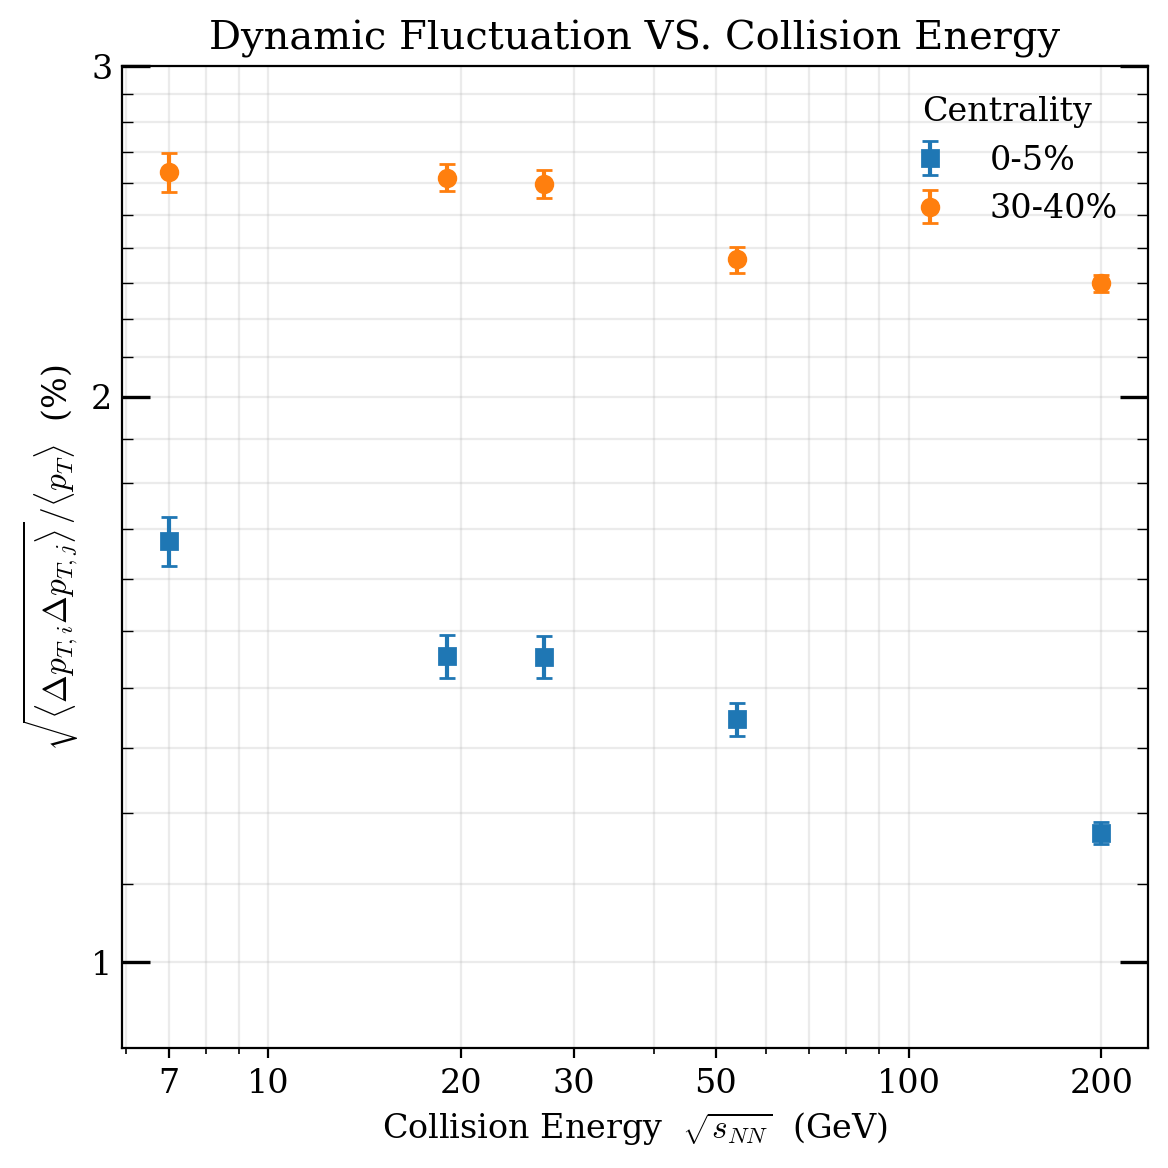

/tmp/ipykernel_32568/2977560172.py:224: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Centrality", frameon=False)


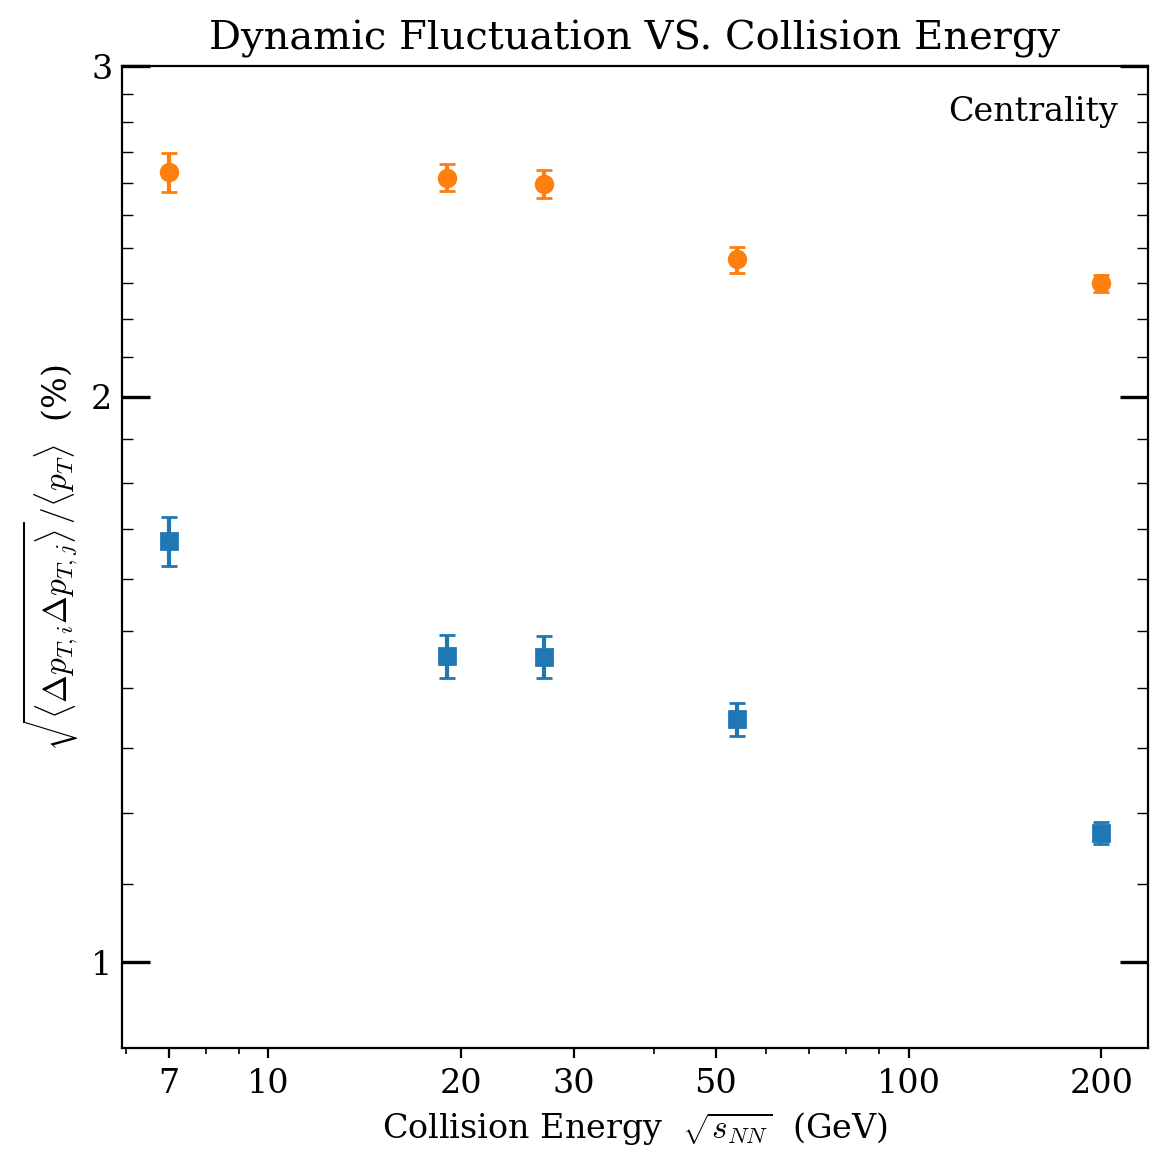

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# all_points is list of (energy_GeV, est_idx, cent_label, y, yerr)
# where energy_GeV = sqrt(sNN) (7, 11.5, 19.6, 27, 39, 54.4, 200, ...)
# and y is already in percent.

plt.figure(figsize=(8.2, 5.6))

# --- styling choices (centrality in legend, estimator separated visually) ---
marker_map = {"0-5%": "s", "30-40%": "o"}     # squares vs circles (like STAR often does)
#est_linestyle = {0: "-", 1: "--", 2: ":", 3: "-."}  # different estimators get different line styles

# Collect all points (you already do this)
all_points = []
for fp in filepaths:
    all_points.extend(get_energy_scan_points_from_file(fp, startpc_group="STARTPC"))

# Group by (centrality, estimator)
groups = {}
for e, est, cent, y, yerr in all_points:
    key = (cent, est)
    groups.setdefault(key, {"x": [], "y": [], "yerr": []})
    groups[key]["x"].append(float(e))
    groups[key]["y"].append(float(y))
    groups[key]["yerr"].append(float(yerr))

# --- plot each group ---
# We'll put centrality in legend, and estimator shown via linestyle (no legend spam)
shown_cent = set()
import numpy as np
import matplotlib.pyplot as plt

# all_points is list of (energy_GeV, est_idx, cent_label, y, yerr)
# where energy_GeV = sqrt(sNN) (7, 11.5, 19.6, 27, 39, 54.4, 200, ...)
# and y is already in percent.

plt.figure(figsize=(8.2, 5.6))

# --- styling choices (centrality in legend, estimator separated visually) ---
marker_map = {"0-5%": "s", "30-40%": "o"}     # squares vs circles (like STAR often does)
#est_linestyle = {0: "-", 1: "--", 2: ":", 3: "-."}  # different estimators get different line styles

# Collect all points (you already do this)
all_points = []
for fp in filepaths:
    all_points.extend(get_energy_scan_points_from_file(fp, startpc_group="STARTPC"))

# Group by (centrality, estimator)
groups = {}
for e, est, cent, y, yerr in all_points:
    key = (cent, est)
    groups.setdefault(key, {"x": [], "y": [], "yerr": []})
    groups[key]["x"].append(float(e))
    groups[key]["y"].append(float(y))
    groups[key]["yerr"].append(float(yerr))

# --- plot each group ---
# We'll put centrality in legend, and estimator shown via linestyle (no legend spam)
shown_cent = set()

plt.rcParams.update({"text.usetex": False, "mathtext.fontset": "cm",
                     "font.family": "serif", "font.size": 12})
plt.figure(figsize=(6, 6), dpi=200)

for (cent, est), d in sorted(groups.items(), key=lambda t: (t[0][0], t[0][1])):
    x = np.array(d["x"], dtype=float)
    y = np.array(d["y"], dtype=float)
    yerr = np.array(d["yerr"], dtype=float)

    order = np.argsort(x)
    x, y, yerr = x[order], y[order], yerr[order]

    # label only once per centrality (so legend is "0-5%" and "30-40%")
    label = None
    if cent not in shown_cent:
        label = cent
        shown_cent.add(cent)

    plt.errorbar(
        x, y, yerr=yerr,
        fmt=marker_map.get(cent, "o"),
        markersize=6,
        capsize=3,
        #linestyle=est_linestyle.get(est, "-"),
        linewidth=1.5,
        label=label
    )

# --- Axis formatting to match STAR-style plot ---

plt.xscale("log")
plt.yscale("log")   # <-- change this


plt.xlabel(r"Collision Energy  $\sqrt{s_{NN}}$  (GeV)")
plt.ylabel(r"$\sqrt{\langle \Delta p_{T,i}\Delta p_{T,j}\rangle}/\langle p_T\rangle$  (%)")

# nicer log ticks on x
plt.xticks([7, 10, 20, 30, 50, 100, 200],
           ["7", "10", "20", "30", "50", "100", "200"])
#plt.yticks([1,2,3],
 #          ["1,2,3"])

# tighten vertical range around actual values
plt.ylim(0.9, 3.0)

import matplotlib.ticker as ticker
import numpy as np

ax = plt.gca()
ax.set_yscale("log")

# --- Major ticks labeled exactly as 1, 2, 3 ---
ax.yaxis.set_major_locator(ticker.FixedLocator([1, 2, 3]))
ax.yaxis.set_major_formatter(ticker.FixedFormatter(["1", "2", "3"]))

# --- Minor ticks: dense log-like ticks between 1 and 10 (only the ones inside your ylim will show) ---
minor_ticks = []

# ticks from 1.1..1.9
minor_ticks += list(np.arange(1.1, 2.0, 0.1))
# ticks from 2.1..2.9
minor_ticks += list(np.arange(2.1, 3.0, 0.1))
# (optional) if you ever expand up to 4–9 later:
# minor_ticks += list(np.arange(3.1, 10.0, 0.1))

ax.yaxis.set_minor_locator(ticker.FixedLocator(minor_ticks))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

# Make tick marks visible & STAR-ish
ax.tick_params(axis="y", which="major", length=10, width=1.2, direction="in")
ax.tick_params(axis="y", which="minor", length=4, width=0.5, direction="in")

# Right-side ticks too (STAR style)
ax.tick_params(axis="y", which="both", right=True)


plt.title("Dynamic Fluctuation VS. Collision Energy")
plt.grid(True, which="both", alpha=0.25)
plt.legend(title="Centrality", frameon=False)
plt.tight_layout()
plt.show()

plt.rcParams.update({"text.usetex": False, "mathtext.fontset": "cm",
                     "font.family": "serif", "font.size": 12})
plt.figure(figsize=(6, 6), dpi=200)

for (cent, est), d in sorted(groups.items(), key=lambda t: (t[0][0], t[0][1])):
    x = np.array(d["x"], dtype=float)
    y = np.array(d["y"], dtype=float)
    yerr = np.array(d["yerr"], dtype=float)

    order = np.argsort(x)
    x, y, yerr = x[order], y[order], yerr[order]

    # label only once per centrality (so legend is "0-5%" and "30-40%")
    label = None
    if cent not in shown_cent:
        label = cent
        shown_cent.add(cent)

    plt.errorbar(
        x, y, yerr=yerr,
        fmt=marker_map.get(cent, "o"),
        markersize=6,
        capsize=3,
        #linestyle=est_linestyle.get(est, "-"),
        linewidth=1.5,
        label=label
    )

# --- Axis formatting to match STAR-style plot ---

plt.xscale("log")
plt.yscale("log")   # <-- change this


plt.xlabel(r"Collision Energy  $\sqrt{s_{NN}}$  (GeV)")
plt.ylabel(r"$\sqrt{\langle \Delta p_{T,i}\Delta p_{T,j}\rangle}/\langle p_T\rangle$  (%)")

# nicer log ticks on x
plt.xticks([7, 10, 20, 30, 50, 100, 200],
           ["7", "10", "20", "30", "50", "100", "200"])
#plt.yticks([1,2,3],
 #          ["1,2,3"])

# tighten vertical range around actual values
plt.ylim(0.9, 3.0)

import matplotlib.ticker as ticker
import numpy as np

ax = plt.gca()
ax.set_yscale("log")

# --- Major ticks labeled exactly as 1, 2, 3 ---
ax.yaxis.set_major_locator(ticker.FixedLocator([1, 2, 3]))
ax.yaxis.set_major_formatter(ticker.FixedFormatter(["1", "2", "3"]))

# --- Minor ticks: dense log-like ticks between 1 and 10 (only the ones inside your ylim will show) ---
minor_ticks = []

# ticks from 1.1..1.9
minor_ticks += list(np.arange(1.1, 2.0, 0.1))
# ticks from 2.1..2.9
minor_ticks += list(np.arange(2.1, 3.0, 0.1))
# (optional) if you ever expand up to 4–9 later:
# minor_ticks += list(np.arange(3.1, 10.0, 0.1))

ax.yaxis.set_minor_locator(ticker.FixedLocator(minor_ticks))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

# Make tick marks visible & STAR-ish
ax.tick_params(axis="y", which="major", length=10, width=1.2, direction="in")
ax.tick_params(axis="y", which="minor", length=4, width=0.5, direction="in")

# Right-side ticks too (STAR style)
ax.tick_params(axis="y", which="both", right=True)


plt.title("Dynamic Fluctuation VS. Collision Energy")
plt.grid(False) #, which="both", alpha=0.25)
plt.legend(title="Centrality", frameon=False)
plt.tight_layout()
plt.show()


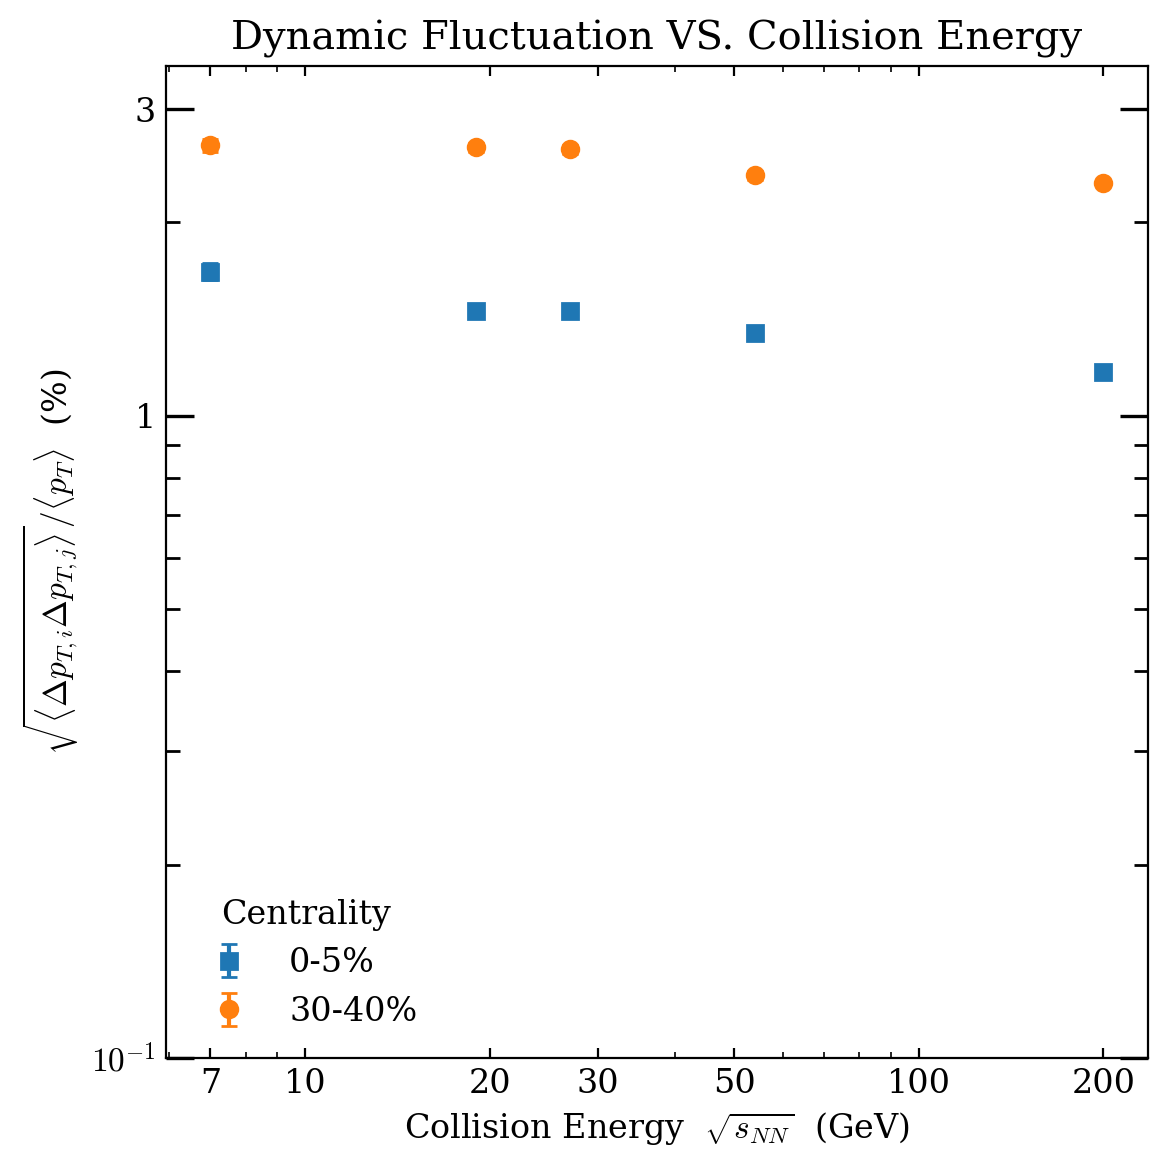

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.size": 12
})

# Collect all points
all_points = []
for fp in filepaths:
    all_points.extend(get_energy_scan_points_from_file(fp, startpc_group="STARTPC"))

# Group by (centrality, estimator)
groups = {}
for e, est, cent, y, yerr in all_points:
    key = (cent, est)
    groups.setdefault(key, {"x": [], "y": [], "yerr": []})
    groups[key]["x"].append(float(e))
    groups[key]["y"].append(float(y))
    groups[key]["yerr"].append(float(yerr))

# ---- Plot once ----
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)

marker_map = {"0-5%": "s", "30-40%": "o"}
shown_cent = set()

for (cent, est), d in sorted(groups.items(), key=lambda t: (t[0][0], t[0][1])):
    x = np.array(d["x"], dtype=float)
    y = np.array(d["y"], dtype=float)
    yerr = np.array(d["yerr"], dtype=float)

    order = np.argsort(x)
    x, y, yerr = x[order], y[order], yerr[order]

    label = None
    if cent not in shown_cent:
        label = cent
        shown_cent.add(cent)

    ax.errorbar(
        x, y, yerr=yerr,
        fmt=marker_map.get(cent, "o"),
        markersize=6,
        capsize=3,
        linewidth=1.5,
        label=label
    )

# Axes
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"Collision Energy  $\sqrt{s_{NN}}$  (GeV)")
ax.set_ylabel(r"$\sqrt{\langle \Delta p_{T,i}\Delta p_{T,j}\rangle}/\langle p_T\rangle$  (%)")

ax.set_xticks([7, 10, 20, 30, 50, 100, 200])
ax.set_xticklabels(["7", "10", "20", "30", "50", "100", "200"])

# ax.set_ylim(1e-1, 3.5)
ax.set_ylim(0.9, 3.5)


# ------------------------------------------------------------
# STAR-style Y ticks: label 10^-1, 1, and ALSO label 3
# (Major ticks fixed; minor ticks are true log subdivisions)
# ------------------------------------------------------------
ax.yaxis.set_major_locator(ticker.FixedLocator([1e-1, 1.0, 3.0]))

class StarMajorFormatter(ticker.Formatter):
    def __call__(self, x, pos=None):
        if np.isclose(x, 1e-1):
            return r"$10^{-1}$"
        if np.isclose(x, 1.0):
            return "1"
        if np.isclose(x, 3.0):
            return "3"
        return ""

ax.yaxis.set_major_formatter(StarMajorFormatter())

# Minor ticks at 2..9 per decade (log-consistent)
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10)))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

# Tick styling (STAR-ish)
ax.tick_params(axis="y", which="major", length=10, width=1.2, direction="in", right=True)
ax.tick_params(axis="y", which="minor", length=5,  width=1.0, direction="in", right=True)
ax.tick_params(axis="x", which="both", direction="in", top=True)

# Grid OFF
ax.grid(False)

ax.set_title("Dynamic Fluctuation VS. Collision Energy")
ax.legend(title="Centrality", frameon=False)
fig.tight_layout()
plt.show()

In [12]:
import pandas as pd

# Convert to DataFrame
df = pd.DataFrame(
    all_points,
    columns=[
        "energy_GeV",
        "estimator",
        "centrality",
        "value_percent",
        "error_percent",
    ],
)

# Sort nicely for readability
df = df.sort_values(["centrality", "estimator", "energy_GeV"])

# Save
out_csv = "pt_fluctuations_energy_scan.csv"
df.to_csv(out_csv, index=False)

print(f"Saved → {out_csv}")
df.head()

Saved → pt_fluctuations_energy_scan.csv


,energy_GeV,estimator,centrality,value_percent,error_percent
0,7.0,0,0-5%,1.676052,0.049927
2,19.0,0,0-5%,1.455347,0.038800
4,27.0,0,0-5%,1.454317,0.037292
6,54.0,0,0-5%,1.346864,0.026884
8,200.0,0,0-5%,1.171245,0.015957
